# 05 · Voltage collapse: P-V nose curves and the Italy 2003 mechanism
*Companion to* **Biggest Power Grid Failures: Engineering Analysis of History's Most Severe Blackouts, Cascades, and Grid Failures** *by Ganesh Kumar Pandey.* See **Chapter 2, Section 2.4 (Figure 2.2)** and **Chapter 7**.

A two-bus model: a strong external source (the UCTE grid) feeds an importing area over tie-lines of total
reactance $X$. Eliminating the angle from Eqs. (2.4)-(2.5) gives

$$V_r^4 + (2QX - V_s^2)V_r^2 + X^2(P^2+Q^2) = 0$$

whose two roots meet at the **nose point**, the maximum power the corridor can deliver.

The Italian story in model form: heavy imports over parallel tie-lines, one line trips (Lukmanier), the
equivalent reactance rises, the nose moves left, and an operating point that was safe is suddenly
beyond the nose. Over-excitation limits on Italian generators then removed reactive support (Eq. 7.1).

> **Model note.** This is a simplified teaching model. Parameters are chosen to be plausible and to reproduce the *shape* of the reported event, not to replicate any operator's measured data. For the authoritative record, read the official report cited in the book. All quantities are per unit on an arbitrary base.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from gridfail import plotstyle as ps
ps.apply()
FIG = os.path.abspath(os.path.join('..', 'figures'))

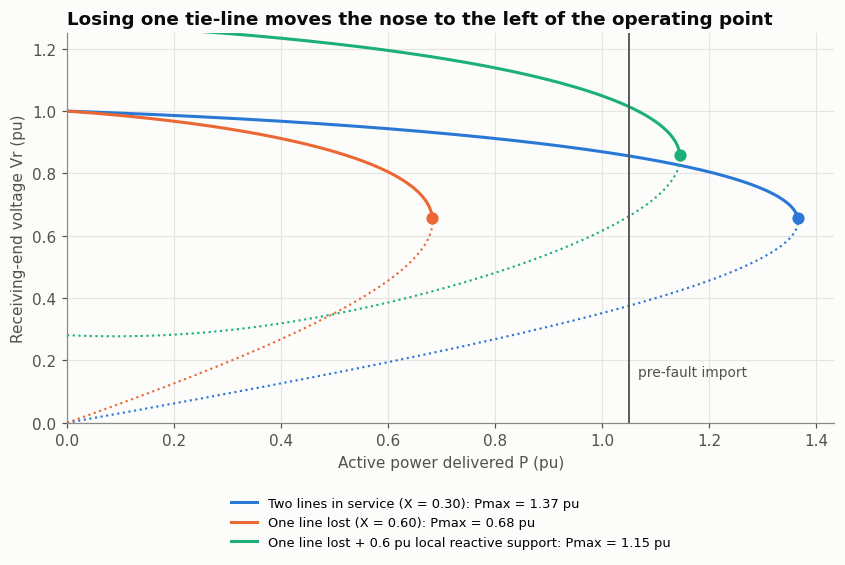

Two lines in service (X = 0.30)            Pmax 1.37 pu   margin   30.1 %   Vr at import: 0.856 pu
One line lost (X = 0.60)                   Pmax 0.68 pu   margin  -35.0 %   Vr at import: beyond nose -> collapse
One line lost + 0.6 pu local reactive support Pmax 1.15 pu   margin    9.1 %   Vr at import: 1.014 pu


In [2]:
from gridfail.voltage import nose_curve, pmax, vr_upper

X_line = 0.6          # pu, one tie-line
TAN = 0.2             # load power factor ~0.98 lagging
P_import = 1.05       # pu, pre-fault import

configs = [('Two lines in service (X = 0.30)', X_line / 2, 0.0),
           ('One line lost (X = 0.60)', X_line, 0.0),
           ('One line lost + 0.6 pu local reactive support', X_line, 0.6)]

fig, ax = plt.subplots()
for (lab, X, qc), c in zip(configs, ps.SERIES):
    P, vu, vl = nose_curve(X, TAN, q_comp=qc)
    ax.plot(P, vu, color=c, label=f'{lab}: Pmax = {P.max():.2f} pu')
    ax.plot(P, vl, color=c, ls=':', lw=1.4)
    ax.plot(P[-1], vu[-1], 'o', color=c, ms=7)
ax.axvline(P_import, color=ps.TEXT2, lw=1.2)
ax.annotate('pre-fault import', xy=(P_import, 0.15), xytext=(6, 0), textcoords='offset points', color=ps.TEXT2, fontsize=9)
ax.set_xlabel('Active power delivered P (pu)'); ax.set_ylabel('Receiving-end voltage Vr (pu)')
ax.set_title('Losing one tie-line moves the nose to the left of the operating point')
ax.set_ylim(0, 1.25); ax.set_xlim(0, None)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=1, fontsize=8.5)
fig.savefig(os.path.join(FIG, '05_pv_nose_italy.png'))
plt.show()

for lab, X, qc in configs:
    pm = pmax(X, TAN, q_comp=qc)
    v = float(vr_upper(P_import, P_import * TAN - qc, X))
    print(f"{lab:42s} Pmax {pm:4.2f} pu   margin {100*(pm-P_import)/P_import:6.1f} %   Vr at import: "
          + ('beyond nose -> collapse' if np.isnan(v) else f'{v:.3f} pu'))

## Why generator reactive limits make it worse (Eq. 7.1)

$Q_{max,field} = \dfrac{V_t E_f}{X_s} - \dfrac{V_t^2}{X_s}$. As terminal voltage falls, the reactive power a
field-limited generator can supply falls too, exactly when the network needs more of it.

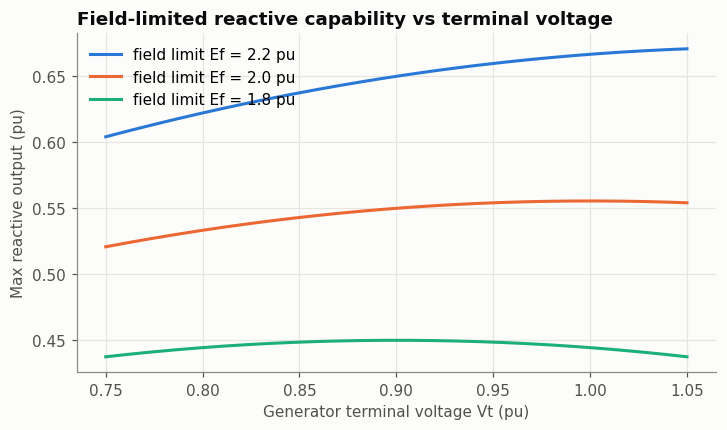

In [3]:
Vt = np.linspace(0.75, 1.05, 200)
Xs = 1.8
fig, ax = plt.subplots(figsize=(7.5, 4))
for Ef, c in zip([2.2, 2.0, 1.8], ps.SERIES):
    ax.plot(Vt, Vt * Ef / Xs - Vt**2 / Xs, color=c, label=f'field limit Ef = {Ef} pu')
ax.set_xlabel('Generator terminal voltage Vt (pu)'); ax.set_ylabel('Max reactive output (pu)')
ax.set_title('Field-limited reactive capability vs terminal voltage'); ax.legend(loc='upper left')
fig.savefig(os.path.join(FIG, '05_field_limit.png'))
plt.show()

**Reading the result.** With both lines in, the import sits comfortably left of the nose. Lose one
line and the same import is no longer deliverable at any voltage, so voltage collapses rather than
merely sagging. Local reactive support near the load (FACTS/STATCOM, Chapter 20) pushes the nose back
to the right, which is why the book's lessons call for reactive compensation near import-dependent load
centres.